## Setup

In [1]:
import pandas as pd
import numpy as np
import os
from langchain_community.document_loaders import PyPDFLoader, UnstructuredPDFLoader, PyPDFium2Loader
from langchain.document_loaders import PyPDFDirectoryLoader, DirectoryLoader
from langchain.text_splitter import RecursiveCharacterTextSplitter
from pathlib import Path
import random
import ollama
import networkx as nx
import hypernetx as hnx 
import matplotlib.pyplot as plt



## Input data directory
data_dir = "PFAS_test"
inputdirectory = Path(f"./data_input/{data_dir}")
## This is where the output csv files will be written
out_dir = data_dir
outputdirectory = Path(f"./data_output/{out_dir}")

## Load Documents

In [2]:
## Dir PDF Loader
#loader = PyPDFDirectoryLoader(inputdirectory)
## File Loader
#loader = PyPDFLoader("./data/MedicalDocuments/orf-path_health-n1.pdf")
loader = DirectoryLoader(inputdirectory, show_progress=True)
documents = loader.load()

100%|██████████| 1/1 [00:01<00:00,  1.27s/it]


## Extract Concepts

In [4]:
## This function uses the helpers/prompt function to extract concepts from text
from helpers.df_helpers import docs2Graph
from helpers.df_helpers import docs2Hypergraph

# Standard KG generation

If regenerate is set to True then the dataframes are regenerated and Both the dataframes are written in the csv format so we dont have to calculate them again. 

        dfne = dataframe of edges

        df = dataframe of chunks


Else the dataframes are read from the output directory

In [2]:
# To regenerate the graph with LLM, set this to True
regenerate = False

if regenerate:
    # Generate concepts list from full text documents (no chunking)
   # G_graph = docs2Graph(documents, model='codellama:13b-instruct')
    G_graph = docs2Graph(documents, model='mistral:instruct')
    # Convert to DataFrame from the graph
    dfg1 = nx.to_pandas_edgelist(G_graph)
    #save the graph
    nx.write_graphml(G_graph, "output_graph.graphml")

else: 
    G_graph = nx.read_graphml("output_graph.graphml")
    dfg1 = nx.to_pandas_edgelist(G_graph)

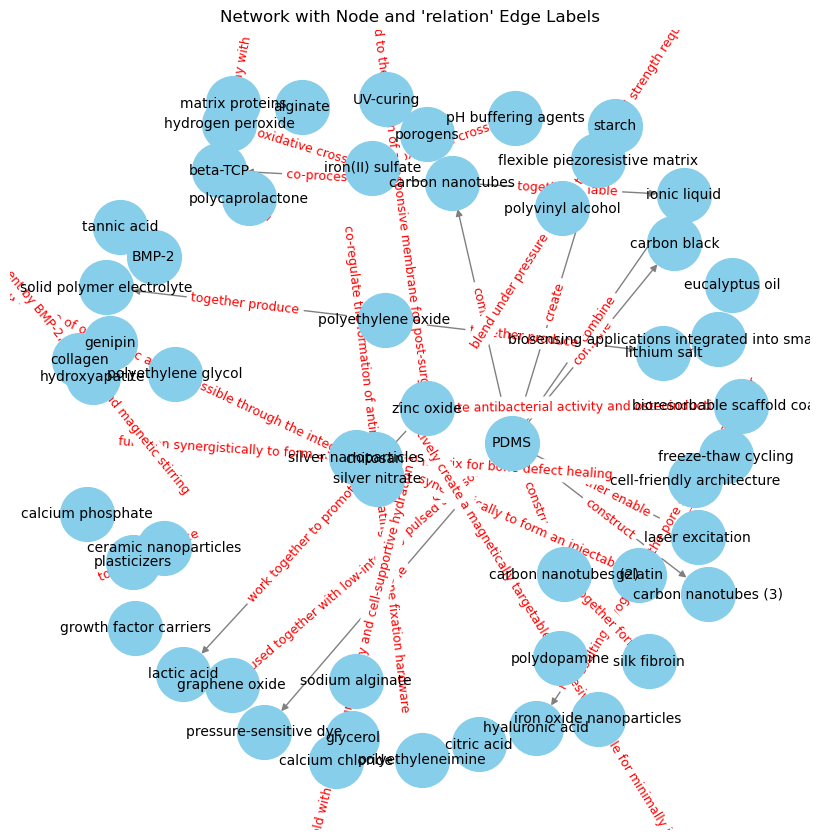

In [6]:
import networkx as nx
import matplotlib.pyplot as plt

# Generate layout
pos = nx.spring_layout(G_graph, seed=42)  # You can try other layouts too

# Draw nodes and edges
nx.draw(G_graph, pos, with_labels=True, node_color='skyblue', edge_color='gray', node_size=1500, font_size=10)

# Use the correct edge attribute for labels
edge_labels = nx.get_edge_attributes(G_graph, 'relation')
nx.draw_networkx_edge_labels(G_graph, pos, edge_labels=edge_labels, font_color='red', font_size=9)

# Show plot
plt.title("Network with Node and 'relation' Edge Labels")
plt.show()


In [4]:
print(type(G_graph))
print(f"Generated graph with {G_graph.number_of_nodes()} nodes and {G_graph.number_of_edges()} edges.")
print("Graph info:")
# List all nodes
print("Nodes:", G_graph.nodes())
# List all edges
# Print only the relation values from each edge
#for u, v, data in G_graph.edges(data=True):
 #   print(data.get('relation'))

<class 'networkx.classes.digraph.DiGraph'>
Generated graph with 54 nodes and 35 edges.
Graph info:
Nodes: ['PDMS', 'carbon black', 'iron(II) sulfate', 'hydrogen peroxide', 'pH buffering agents', 'matrix proteins', 'zinc oxide', 'lactic acid', 'polyethylene oxide', 'lithium salt', 'ceramic nanoparticles', 'plasticizers', 'chitosan', 'genipin', 'gelatin', 'hyaluronic acid', 'carbon nanotubes', 'ionic liquid', 'pressure-sensitive dye', 'laser excitation', 'polyvinyl alcohol', 'silver nitrate', 'beta-TCP', 'porogens', 'citric acid', 'eucalyptus oil', 'starch', 'silver nanoparticles', 'growth factor carriers', 'calcium phosphate', 'glycerol', 'polyethylene glycol', 'BMP-2', 'alginate', 'carbon nanotubes (2)', 'silk fibroin', 'tannic acid', 'polydopamine', 'iron oxide nanoparticles', 'polyethyleneimine', 'sodium alginate', 'calcium chloride', 'graphene oxide', 'flexible piezoresistive matrix', 'bioresorbable scaffold coatings', 'solid polymer electrolyte', 'biosensing applications integrated

# Hypergraph Generation

In [ ]:
"""
import pickle
import pandas as pd

# To regenerate the hypergraph with LLM, set this to True
regenerate = True

if regenerate:
    # Generate hypergraph from full text documents
    H_hypergraph = docs2Hypergraph(documents, model='mistral:instruct')
    
    # Save as pickle (recommended format for HyperNetX)
    with open("output_hypergraph.pkl", "wb") as f:
        pickle.dump(H_hypergraph, f)

    # Optional: convert hyperedges to DataFrame
    dfg1 = pd.DataFrame([
        {"event": hedge, "entity": node}
        for hedge, nodes in H_hypergraph.incidence_dict.items()
        for node in nodes
    ])

    # Save DataFrame for inspection
    dfg1.to_csv("output_hypergraph_edges.csv", index=False)

else:
    # Load from pickle
    with open("output_hypergraph.pkl", "rb") as f:
        H_hypergraph = pickle.load(f)

    # Reconstruct DataFrame
    dfg1 = pd.DataFrame([
        {"event": hedge, "entity": node}
        for hedge, nodes in H_hypergraph.incidence_dict.items()
        for node in nodes
    ])
"""

Generating hypergraph events...
 [
  {
    "id": "PDMS and carbon black combine to create a flexible, piezoresistive matrix ideal for embedding strain sensors in load-bearing tissue constructs.",
    "entities": ["PDMS", "carbon black"]
  },
  {
    "id": "The mechanical resilience of engineered bone grafts relies on the interplay between iron(II) sulfate, hydrogen peroxide, and pH buffering agents during oxidative crosslinking of matrix proteins.",
    "entities": ["iron(II) sulfate", "hydrogen peroxide", "pH buffering agents"]
  },
  {
    "id": "Zinc oxide and lactic acid work together to promote antibacterial activity and osteoinductivity in bioresorbable scaffold coatings.",
    "entities": ["Zinc oxide", "lactic acid"]
  },
  {
    "id": "Polyethylene oxide, lithium salt, ceramic nanoparticles, and plasticizers together produce a solid polymer electrolyte useful for biosensing applications integrated into smart bone implants.",
    "entities": ["Polyethylene oxide", "lithium salt

AttributeError: 'tuple' object has no attribute 'incidence_dict'

In [5]:
import pickle
import pandas as pd

# To regenerate the hypergraph with LLM, set this to True
regenerate = True

if regenerate:
    # Generate hypergraph and mapping from full text documents
    H_hypergraph, edge_mapping = docs2Hypergraph(documents, model='mistral:instruct')
    
    # Save as pickle
    with open("output_hypergraph_test_instruct.pkl", "wb") as f:
        pickle.dump(H_hypergraph, f)

    # Convert hyperedges to DataFrame
    dfg1 = pd.DataFrame([
        {"event": hedge, "entity": node}
        for hedge, nodes in H_hypergraph.incidence_dict.items()
        for node in nodes
    ])

    # Save CSV
    dfg1.to_csv("output_hypergraph_edges_test_instruct.csv", index=False)

else:
    # Load from pickle
    with open("output_hypergraph_test_instruct.pkl", "rb") as f:
        H_hypergraph = pickle.load(f)

    # Reconstruct DataFrame
    dfg1 = pd.DataFrame([
        {"event": hedge, "entity": node}
        for hedge, nodes in H_hypergraph.incidence_dict.items()
        for node in nodes
    ])


Generating hypergraph events...
=== Parsed LLM Response ===
events=[Event(id='PDMS and carbon black combine to create a flexible, piezoresistive matrix', entities=['PDMS', 'carbon black', 'matrix']), Event(id='The mechanical resilience of engineered bone grafts relies on the interplay between iron(II) sulfate, hydrogen peroxide, and pH buffering agents during oxidative crosslinking of matrix proteins', entities=['engineered bone grafts', 'iron(II) sulfate', 'hydrogen peroxide', 'pH buffering agents', 'oxidative crosslinking', 'matrix proteins'])]
Generated hypergraph with 9 nodes and 2 relabeled hyperedges.


In [6]:
print(type(H_hypergraph))
print(f"Generated hypergraph with {len(H_hypergraph.nodes)} nodes and {len(H_hypergraph.edges)} hyperedges.")

<class 'hypernetx.classes.hypergraph.Hypergraph'>
Generated hypergraph with 9 nodes and 2 hyperedges.


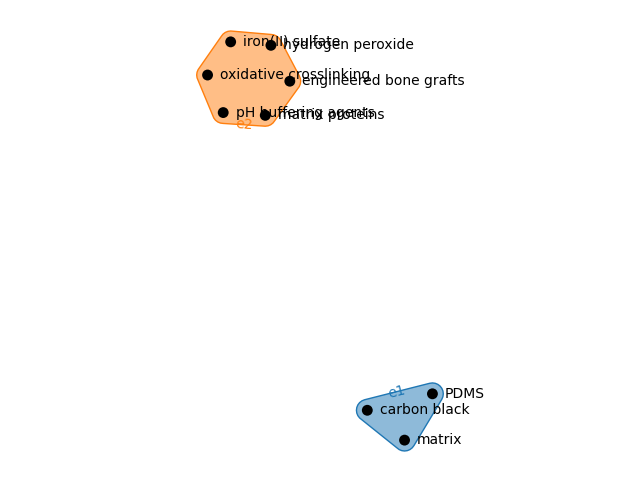

In [7]:
plt.figure(figsize=(8, 6))
hnx.draw(H_hypergraph, fill_edges=True, node_label_alpha=0.0, edge_label_alpha=0.0)
plt.savefig("hypergraph_visualization.png", dpi=300, bbox_inches="tight")
plt.show()

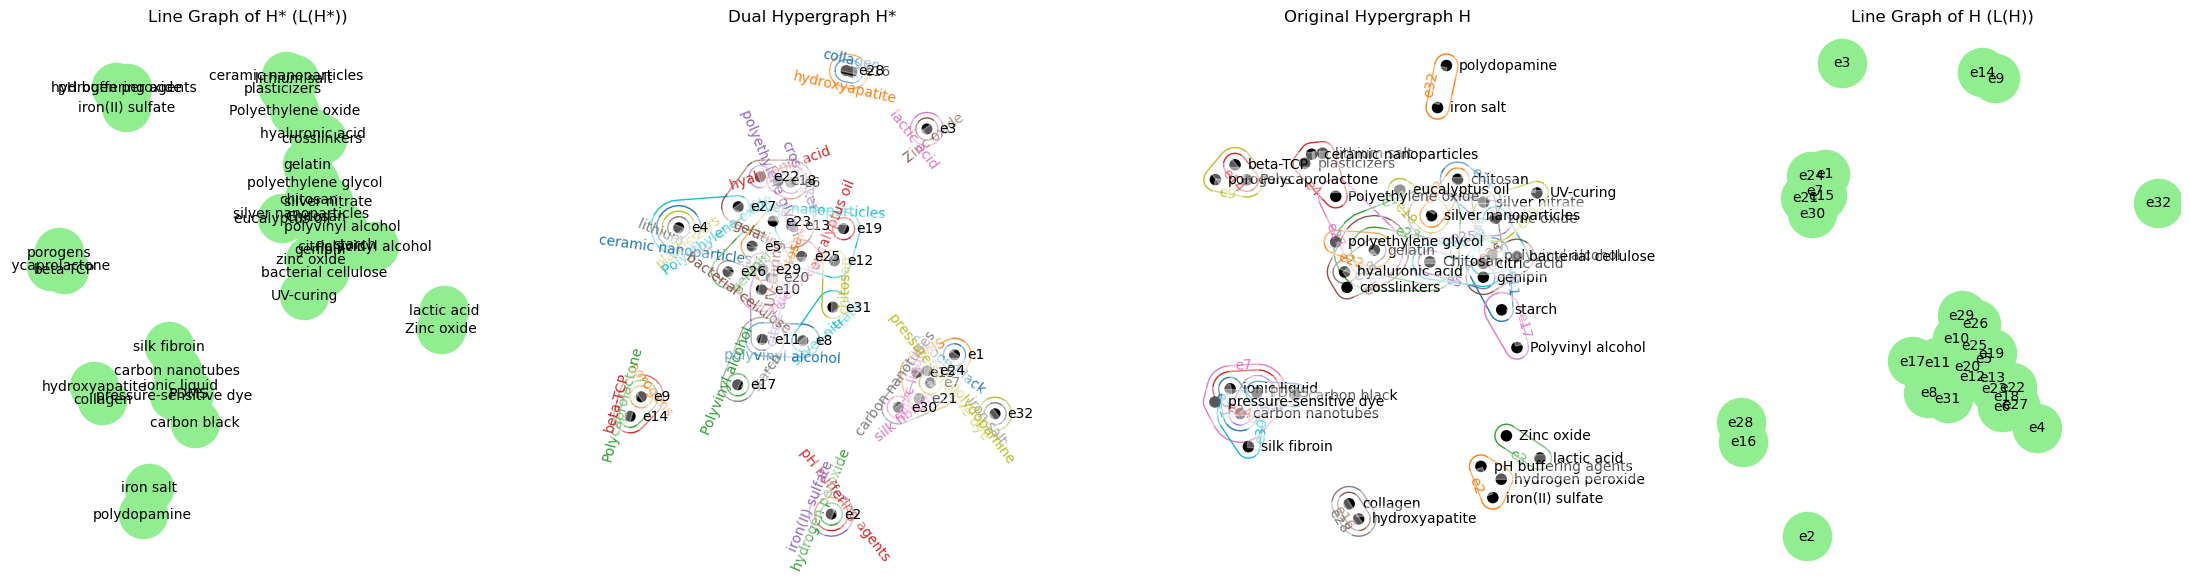

In [7]:
import hypernetx as hnx
import networkx as nx
import matplotlib.pyplot as plt

# === Step 1: Use your hypergraph H ===
# Ensure H is already defined before running this script
# H = your HyperNetX hypergraph

# === Step 2: Compute dual hypergraph H* ===
H_star = H.dual()

# === Step 3: Compute s=1 line graphs of H and H* ===
L_H = H.get_linegraph(s=1)
L_H_star = H_star.get_linegraph(s=1)

# === Step 4: Create the 2x2 plot ===
fig, axes = plt.subplots(1, 4, figsize=(22, 6))

titles = [
    "Line Graph of H* (L(H*))",
    "Dual Hypergraph H*",
    "Original Hypergraph H",
    "Line Graph of H (L(H))"
]
objects = [L_H_star, H_star, H, L_H]

# === Step 5: Draw each ===
for ax, obj, title in zip(axes, objects, titles):
    ax.set_title(title)

    if isinstance(obj, hnx.Hypergraph):
        hnx.draw(obj, ax=ax, with_edge_labels=True, with_node_labels=True)
    elif isinstance(obj, nx.Graph):
        pos = nx.spring_layout(obj, seed=42)
        nx.draw(obj, pos, ax=ax, with_labels=True, node_color='lightgreen', node_size=1200, font_size=10)
    else:
        raise TypeError("Unsupported object type.")

plt.tight_layout()
plt.show()


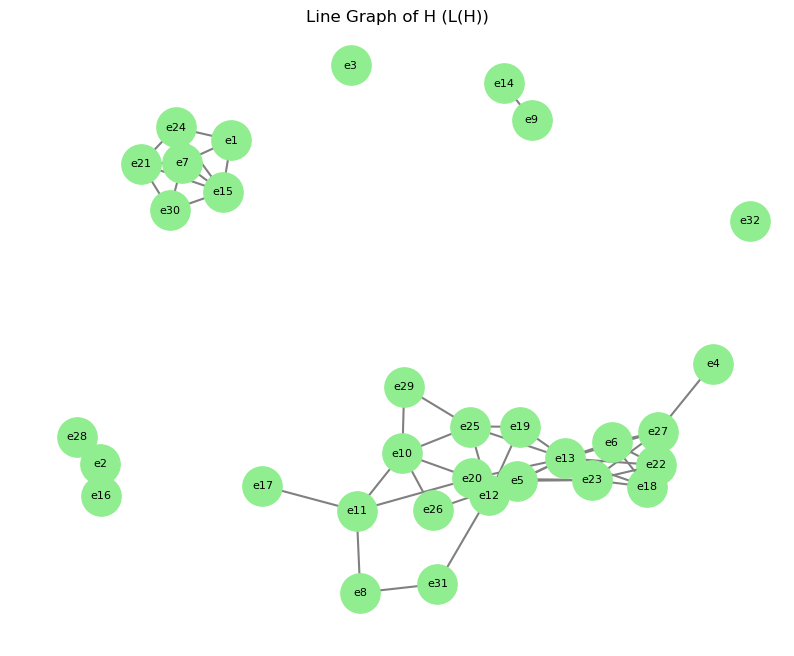

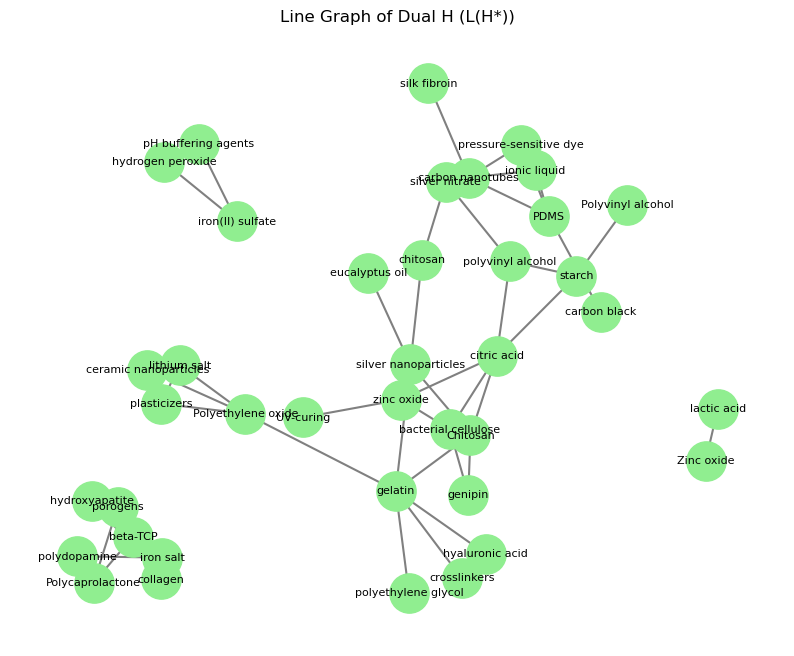

In [9]:
import matplotlib.pyplot as plt
import networkx as nx

def draw_line_graph(G_line, title="Line Graph"):
    plt.figure(figsize=(10, 8))  # Bigger figure
    pos = nx.spring_layout(G_line, seed=42, k=0.4)  # More spread
    nx.draw_networkx_nodes(G_line, pos, node_size=800, node_color='lightgreen')
    nx.draw_networkx_edges(G_line, pos, edge_color='gray', width=1.5)
    nx.draw_networkx_labels(G_line, pos, font_size=8, font_color='black')
    plt.title(title)
    plt.axis("off")
    plt.show()

# Use the line graph methods from hypernetx
L_H = H.get_linegraph(s=1)
L_H_star = H.dual().get_linegraph(s=1)

# Draw both
draw_line_graph(L_H, "Line Graph of H (L(H))")
draw_line_graph(L_H_star, "Line Graph of Dual H (L(H*))")


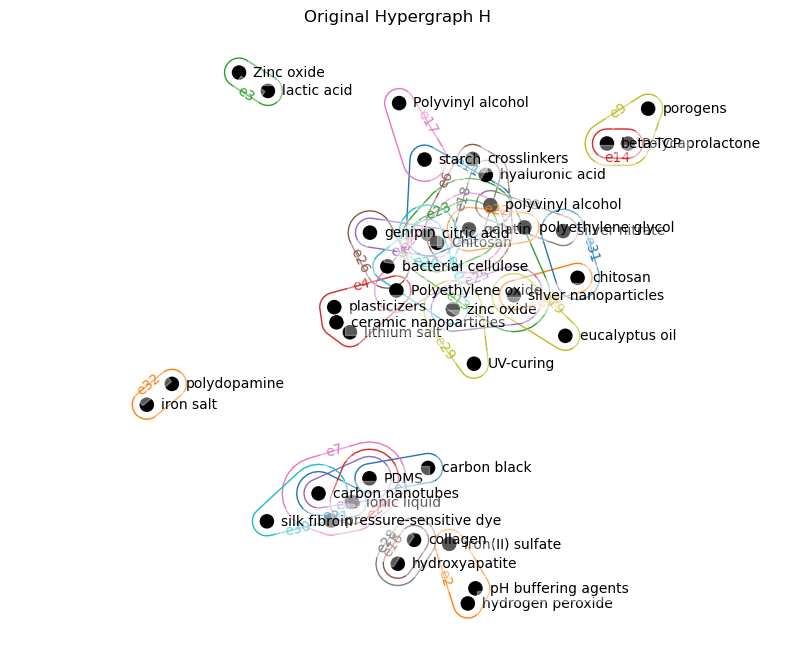

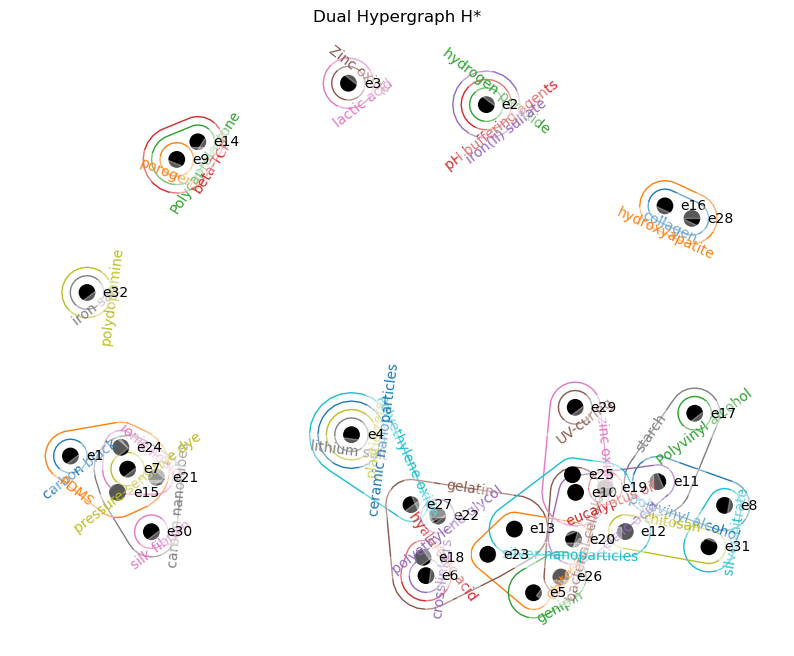

In [11]:
import matplotlib.pyplot as plt
import hypernetx as hnx

def draw_hypergraph(H, title="Hypergraph"):
    plt.figure(figsize=(10, 8))  # adjust as needed
    hnx.draw(H, with_node_labels=True, with_edge_labels=True)
    plt.title(title)
    plt.show()

# Your original hypergraph H
draw_hypergraph(H, "Original Hypergraph H")

# Dual hypergraph H*
H_dual = H.dual()
draw_hypergraph(H_dual, "Dual Hypergraph H*")


In [8]:
print("L(H) edges (s=1):", list(L_H.edges()))
print("L(H*) edges (s=1):", list(L_H_star.edges()))

L(H) edges (s=1): [('e1', 'e15'), ('e1', 'e24'), ('e1', 'e7'), ('e10', 'e11'), ('e10', 'e20'), ('e10', 'e25'), ('e10', 'e26'), ('e10', 'e29'), ('e11', 'e17'), ('e11', 'e20'), ('e11', 'e8'), ('e12', 'e13'), ('e12', 'e19'), ('e12', 'e25'), ('e12', 'e31'), ('e13', 'e18'), ('e13', 'e19'), ('e13', 'e20'), ('e13', 'e22'), ('e13', 'e23'), ('e13', 'e25'), ('e13', 'e27'), ('e13', 'e5'), ('e13', 'e6'), ('e14', 'e9'), ('e15', 'e21'), ('e15', 'e24'), ('e15', 'e30'), ('e15', 'e7'), ('e16', 'e28'), ('e18', 'e22'), ('e18', 'e23'), ('e18', 'e27'), ('e18', 'e6'), ('e19', 'e25'), ('e20', 'e23'), ('e20', 'e5'), ('e21', 'e24'), ('e21', 'e30'), ('e21', 'e7'), ('e22', 'e23'), ('e22', 'e27'), ('e22', 'e6'), ('e23', 'e27'), ('e23', 'e5'), ('e23', 'e6'), ('e24', 'e7'), ('e25', 'e29'), ('e26', 'e5'), ('e27', 'e4'), ('e27', 'e6'), ('e30', 'e7'), ('e31', 'e8')]
L(H*) edges (s=1): [('Chitosan', 'citric acid'), ('Chitosan', 'gelatin'), ('Chitosan', 'genipin'), ('Chitosan', 'silver nanoparticles'), ('PDMS', 'carbon 

In [6]:
H = H_hypergraph
H.incidences.dataframe

weight misc_properties
edges nodes                                      
e1    carbon black            1.0              {}
      PDMS                    1.0              {}
e2    hydrogen peroxide       1.0              {}
      pH buffering agents     1.0              {}
      iron(II) sulfate        1.0              {}
...                           ...             ...
e30   silk fibroin            1.0              {}
e31   chitosan                1.0              {}
      silver nitrate          1.0              {}
e32   iron salt               1.0              {}
      polydopamine            1.0              {}

[74 rows x 2 columns]

In [5]:
import hypernetx as hnx
import networkx as nx
import matplotlib.pyplot as plt

# Assume H is your HyperNetX hypergraph
s = 1  # or s = 2 for tighter connectivity

# Get the s-line graph (edges become nodes, connected if share >= s nodes)
line_graph = H.get_linegraph(s=s)

components = list(nx.connected_components(line_graph))
print(f"# of connected components (s={s}):", len(components))




# of connected components (s=1): 7


/tmp/ipykernel_50151/572120874.py:14: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


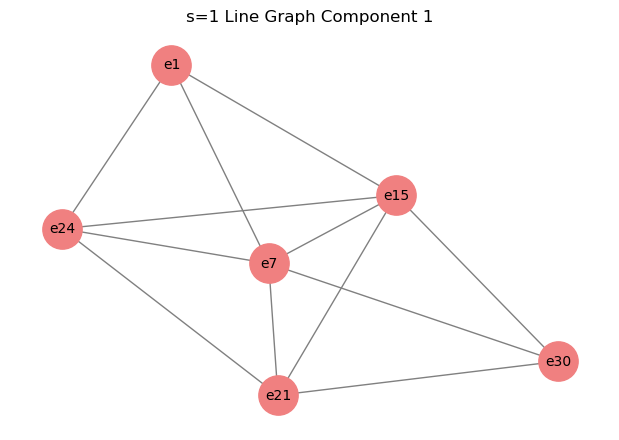

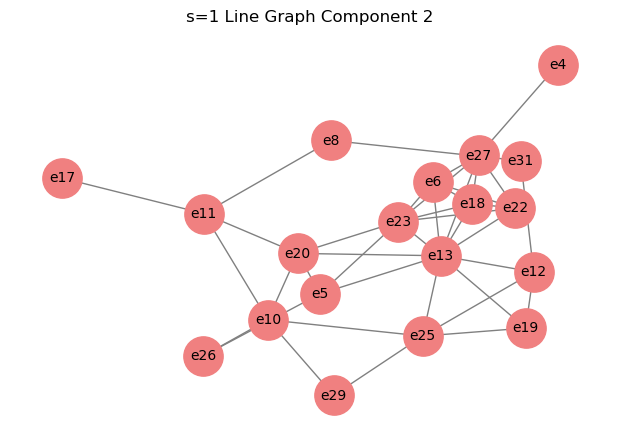

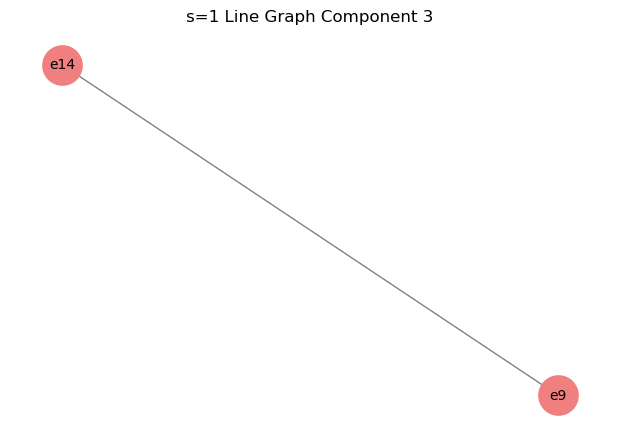

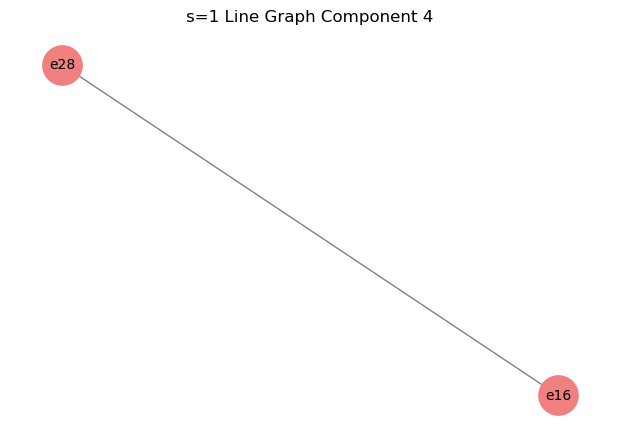

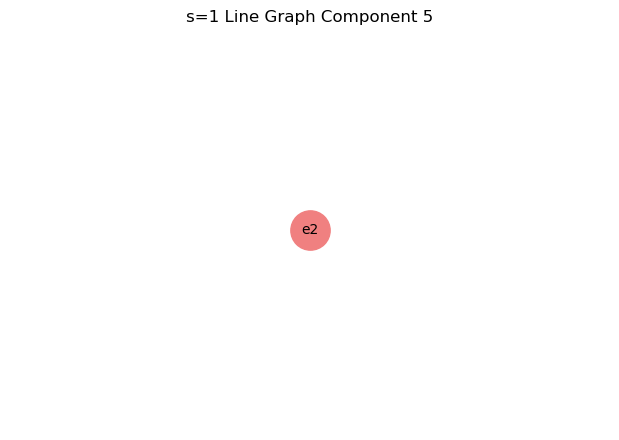

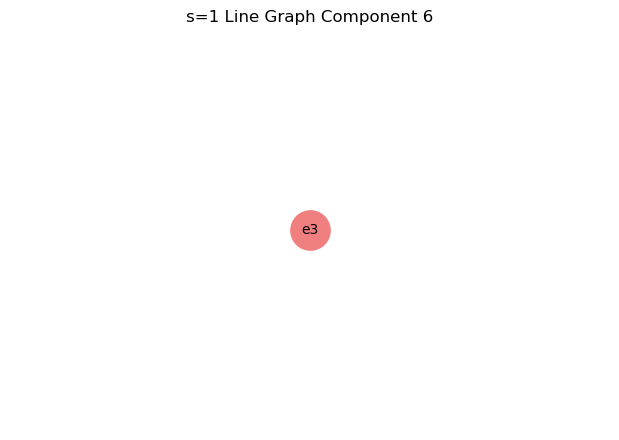

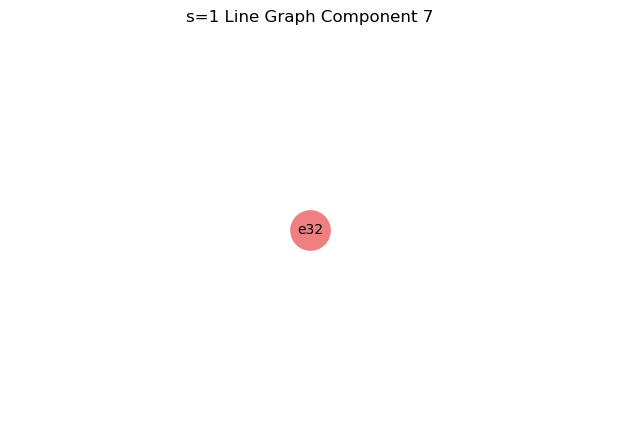

In [6]:
for i, comp in enumerate(components):
    subgraph = line_graph.subgraph(comp)
    
    plt.figure(figsize=(6, 4))
    nx.draw(
        subgraph,
        with_labels=True,
        node_color='lightcoral',
        edge_color='gray',
        node_size=800,
        font_size=10
    )
    plt.title(f"s={s} Line Graph Component {i+1}")
    plt.tight_layout()
    plt.show()


In [15]:
!pip install tabulate

  Using cached tabulate-0.9.0-py3-none-any.whl.metadata (34 kB)
Using cached tabulate-0.9.0-py3-none-any.whl (35 kB)


In [17]:
from collections import Counter
from itertools import combinations
from tabulate import tabulate


def compute_hypergraph_metrics(H, name="Hypergraph"):
    # Edge list
    edge_list = list(H.edges)

    # Number of edges
    num_edges = len(edge_list)

    # Multi-edges (check duplicates)
    edge_sets = [frozenset(H.edges[e]) for e in edge_list]
    multi_edges = len(edge_sets) - len(set(edge_sets))

    # Max edge size
    max_edge_size = max(len(H.edges[e]) for e in edge_list)

    # Max edge intersection size
    inter_sizes = []
    for e1, e2 in combinations(edge_list, 2):
        s1, s2 = set(H.edges[e1]), set(H.edges[e2])
        inter = s1 & s2
        if inter:
            inter_sizes.append(len(inter))
    max_intersection = max(inter_sizes) if inter_sizes else 0

    # Density (basic approximation)
    n = len(H.nodes)
    density = num_edges / (2 ** n - 1) if n > 1 else 0

    return {
        "Name": name,
        "# Edges": num_edges,
        "# Multi-edges": multi_edges,
        "Max edge size": max_edge_size,
        "Max edge inter.": max_intersection,
        "Density": f"{density:.2e}"
    }


# Compute and print metrics for your hypergraph H
results = [
    compute_hypergraph_metrics(H, "MyGraph")
]

print(tabulate(results, headers="keys", tablefmt="fancy_grid"))


╒═════════╤═══════════╤═════════════════╤═════════════════╤═══════════════════╤═══════════╕
│ Name    │   # Edges │   # Multi-edges │   Max edge size │   Max edge inter. │   Density │
╞═════════╪═══════════╪═════════════════╪═════════════════╪═══════════════════╪═══════════╡
│ MyGraph │        32 │               1 │               4 │                 2 │  5.82e-11 │
╘═════════╧═══════════╧═════════════════╧═════════════════╧═══════════════════╧═══════════╛


#  Node Degree
## Where a node's degree is defined as the number of hyperedges it participates in

In [23]:
from collections import defaultdict

# Build node → list of incident edges mapping
node_to_edges = defaultdict(set)

for edge_id, nodes in H_hypergraph.incidence_dict.items():
    for node in nodes:
        node_to_edges[node].add(edge_id)

# Now compute node degrees
node_degrees = {node: len(edges) for node, edges in node_to_edges.items()}

for node, degree in node_degrees.items():
    print(f"{node}: {degree}")

carbon black: 1
PDMS: 4
citric acid: 3
bacterial cellulose: 2
zinc oxide: 3
polyvinyl alcohol: 2
starch: 2
chitosan: 2
silver nanoparticles: 4
Chitosan: 4
gelatin: 6
Polycaprolactone: 2
beta-TCP: 2
carbon nanotubes: 4
collagen: 2
hydroxyapatite: 2
Polyvinyl alcohol: 1
hyaluronic acid: 2
eucalyptus oil: 1
hydrogen peroxide: 1
pH buffering agents: 1
iron(II) sulfate: 1
ionic liquid: 3
polyethylene glycol: 1
genipin: 2
Polyethylene oxide: 2
UV-curing: 1
Zinc oxide: 1
lactic acid: 1
silk fibroin: 1
silver nitrate: 2
iron salt: 1
polydopamine: 1
lithium salt: 1
plasticizers: 1
ceramic nanoparticles: 1
crosslinkers: 1
pressure-sensitive dye: 1
porogens: 1


In [12]:
from collections import defaultdict

# Build node → list of incident edges mapping
node_to_edges = defaultdict(set)

for edge_id, nodes in H_hypergraph.incidence_dict.items():
    for node in nodes:
        node_to_edges[node].add(edge_id)

# Compute node degrees
node_degrees = {node: len(edges) for node, edges in node_to_edges.items()}

# Sort and print top 5 nodes by degree
top_5 = sorted(node_degrees.items(), key=lambda x: x[1], reverse=True)[:5]
print("Top 5 nodes by degree:")
for node, degree in top_5:
    print(f"{node}: {degree}")


Top 5 nodes by degree:
gelatin: 6
PDMS: 4
silver nanoparticles: 4
Chitosan: 4
carbon nanotubes: 4


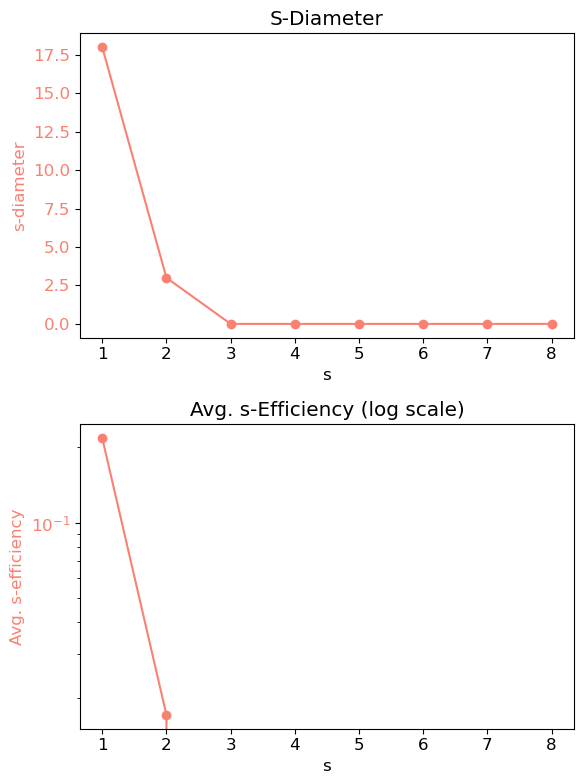

In [31]:
import matplotlib.pyplot as plt
import networkx as nx
import hypernetx as hnx

# Your hypergraph object
H = H  # Replace with your actual hypergraph object

def s_diameter(H, s=1):
    G = H.get_linegraph(s=s, edges=True)
    try:
        components = nx.connected_components(G)
        return max(len(c) for c in components) - 1
    except:
        return 0

def s_efficiency(H, s=1):
    G = H.get_linegraph(s=s, edges=True)
    nodes = list(G.nodes)
    n = len(nodes)
    if n <= 1:
        return 0
    path_lengths = []
    for i in range(n):
        for j in range(i + 1, n):
            try:
                length = nx.shortest_path_length(G, nodes[i], nodes[j])
                path_lengths.append(1 / length)
            except nx.NetworkXNoPath:
                continue
    return (2 / (n * (n - 1))) * sum(path_lengths) if path_lengths else 0

# Compute over range of s
s_values = list(range(1, 9))
diameters = [s_diameter(H, s) for s in s_values]
efficiencies = [s_efficiency(H, s) for s in s_values]

# Salmon pink color
salmon = "#FA8072"

# Plot side-by-side subplots
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(6, 8))

# Plot s-diameter
ax1.plot(s_values, diameters, 'o-', color=salmon)
ax1.set_xlabel("s")
ax1.set_ylabel("s-diameter", color=salmon)
ax1.set_title("S-Diameter")
ax1.tick_params(axis='y', labelcolor=salmon)
ax1.grid(False)  # Turn off grid

# Plot s-efficiency
ax2.plot(s_values, efficiencies, 'o-', color=salmon)
ax2.set_xlabel("s")
ax2.set_ylabel("Avg. s-efficiency", color=salmon)
ax2.set_yscale('log')
ax2.set_title("Avg. s-Efficiency (log scale)")
ax2.tick_params(axis='y', labelcolor=salmon)
ax2.grid(False)  # Turn off grid

plt.tight_layout()
plt.savefig("lesmis_smetrics_salmon.png", dpi=300, bbox_inches='tight')
plt.show()



In [24]:
efficiencies = [e if e > 0 else 1e-3 for e in efficiencies]
print(efficiencies)

[0.21686827956989227, 0.017137096774193547, 0.001, 0.001, 0.001, 0.001, 0.001, 0.001]


# Edge Size
## size of each hyperedge

In [24]:
H = H_hypergraph
edge_sizes = {e: len(H.edges[e]) for e in H.edges}

for edge, size in edge_sizes.items():
    print(f"{edge}: {size}")

e1: 2
e2: 3
e3: 2
e4: 4
e5: 2
e6: 3
e7: 4
e8: 2
e9: 3
e10: 3
e11: 3
e12: 2
e13: 3
e14: 2
e15: 2
e16: 2
e17: 2
e18: 2
e19: 2
e20: 2
e21: 2
e22: 2
e23: 2
e24: 2
e25: 2
e26: 2
e27: 2
e28: 2
e29: 2
e30: 2
e31: 2
e32: 2


In [13]:
H = H_hypergraph
edge_sizes = {e: len(H.edges[e]) for e in H.edges}

# Sort and print top 5 largest edges by size
top_5_edges = sorted(edge_sizes.items(), key=lambda x: x[1], reverse=True)[:5]
print("Top 5 hyperedges by number of nodes:")
for edge, size in top_5_edges:
    print(f"{edge}: {size}")

Top 5 hyperedges by number of nodes:
e4: 4
e7: 4
e2: 3
e6: 3
e9: 3


In [8]:
from collections import defaultdict

def compute_s_component_metrics(H, s=1):
    components = list(H.s_connected_components(s=s, edges=True))
    metrics = []

    for i, component in enumerate(components):
        # Get all nodes in the component's edges
        nodes_in_component = set()
        for e in component:
            nodes_in_component.update(H.edges[e])
        
        # Compute degree of each node within this component
        node_degree_in_comp = defaultdict(int)
        for e in component:
            for node in H.edges[e]:
                node_degree_in_comp[node] += 1

        # Compute p-smoothness
        smooth_sum = 0
        for e in component:
            edge_nodes = H.edges[e]
            edge_sum = sum(node_degree_in_comp[v] for v in edge_nodes)
            smooth_sum += edge_sum / len(edge_nodes)
        p_smoothness = smooth_sum / len(component)

        # Compute dispersion
        total_nodes = len(nodes_in_component)
        total_mentions = sum(len(H.edges[e]) for e in component)
        dispersion = total_nodes / total_mentions if total_mentions > 0 else 0

        metrics.append({
            "Component": f"C{i+1}",
            "Num Edges": len(component),
            "Num Nodes": total_nodes,
            "p-smoothness": round(p_smoothness, 4),
            "dispersion": round(dispersion, 4)
        })

    return metrics
metrics = compute_s_component_metrics(H_hypergraph, s=1)

# Pretty print
from tabulate import tabulate
print(tabulate(metrics, headers="keys", tablefmt="fancy_grid"))

╒═════════════╤═════════════╤═════════════╤════════════════╤══════════════╕
│ Component   │   Num Edges │   Num Nodes │   p-smoothness │   dispersion │
╞═════════════╪═════════════╪═════════════╪════════════════╪══════════════╡
│ C1          │           6 │           6 │         3.1667 │       0.4286 │
├─────────────┼─────────────┼─────────────┼────────────────┼──────────────┤
│ C2          │          19 │          21 │         2.9167 │       0.4773 │
├─────────────┼─────────────┼─────────────┼────────────────┼──────────────┤
│ C3          │           2 │           3 │         1.8333 │       0.6    │
├─────────────┼─────────────┼─────────────┼────────────────┼──────────────┤
│ C4          │           2 │           2 │         2      │       0.5    │
╘═════════════╧═════════════╧═════════════╧════════════════╧══════════════╛


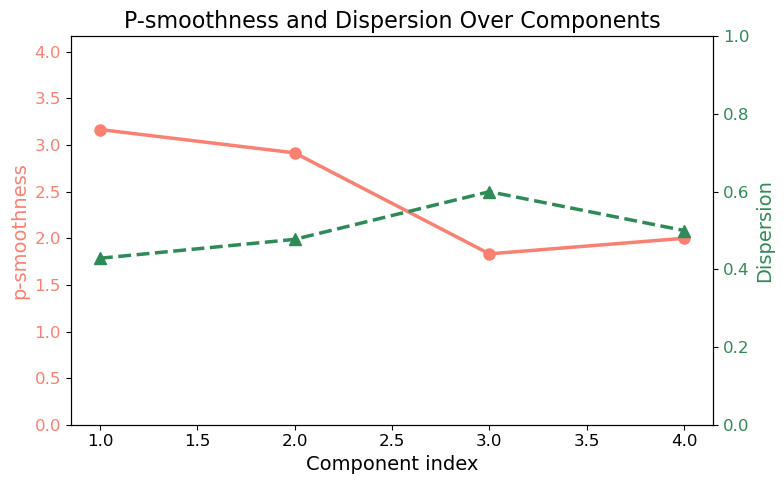

In [30]:
import matplotlib.pyplot as plt

# Salmon pink and complementary green colors
salmon_pink = '#FA8072'
complementary_green = '#2E8B57'  # SeaGreen

x_vals = range(1, len(p_smoothness_vals) + 1)

fig, ax1 = plt.subplots(figsize=(8, 5))  # Make the figure slightly larger

# Left y-axis for p-smoothness
ax1.set_xlabel("Component index", fontsize=14)
ax1.set_ylabel("p-smoothness", color=salmon_pink, fontsize=14)
ax1.plot(x_vals, p_smoothness_vals, 'o-', color=salmon_pink, linewidth=2.5, markersize=8, label=r"$p$-smoothness")
ax1.tick_params(axis='y', labelcolor=salmon_pink, labelsize=12)
ax1.tick_params(axis='x', labelsize=12)
ax1.set_ylim(0, max(p_smoothness_vals) + 1)

# Right y-axis for dispersion
ax2 = ax1.twinx()
ax2.set_ylabel("Dispersion", color=complementary_green, fontsize=14)
ax2.plot(x_vals, dispersion_vals, '^--', color=complementary_green, linewidth=2.5, markersize=8, label="Dispersion")
ax2.tick_params(axis='y', labelcolor=complementary_green, labelsize=12)
ax2.set_ylim(0, 1)

# Title and layout
plt.title("P-smoothness and Dispersion Over Components", fontsize=16)
fig.tight_layout()
plt.savefig("lesmis_metrics_salmon_green.png", dpi=300, bbox_inches='tight')  # Save as PNG
plt.show()


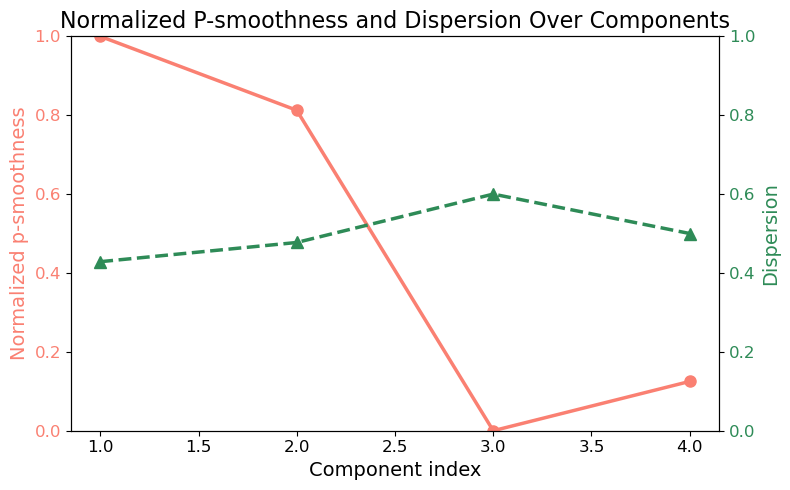

In [10]:
from matplotlib import pyplot as plt

# Extract p-smoothness and dispersion from metrics
p_smoothness_vals = [m["p-smoothness"] for m in metrics]
dispersion_vals = [m["dispersion"] for m in metrics]

# Normalize p-smoothness to [0, 1]
p_min = min(p_smoothness_vals)
p_max = max(p_smoothness_vals)
p_smoothness_norm = [(val - p_min) / (p_max - p_min) for val in p_smoothness_vals]

# Component indices (1-based)
x_vals = list(range(1, len(metrics) + 1))

# Salmon pink and complementary green colors
salmon_pink = '#FA8072'
complementary_green = '#2E8B57'

# Plot
fig, ax1 = plt.subplots(figsize=(8, 5))

# Plot normalized p-smoothness
ax1.set_xlabel("Component index", fontsize=14)
ax1.set_ylabel("Normalized p-smoothness", color=salmon_pink, fontsize=14)
ax1.plot(x_vals, p_smoothness_norm, 'o-', color=salmon_pink, linewidth=2.5, markersize=8)
ax1.tick_params(axis='y', labelcolor=salmon_pink, labelsize=12)
ax1.set_ylim(0, 1)
ax1.tick_params(axis='x', labelsize=12)

# Plot dispersion
ax2 = ax1.twinx()
ax2.set_ylabel("Dispersion", color=complementary_green, fontsize=14)
ax2.plot(x_vals, dispersion_vals, '^--', color=complementary_green, linewidth=2.5, markersize=8)
ax2.tick_params(axis='y', labelcolor=complementary_green, labelsize=12)
ax2.set_ylim(0, 1)

plt.title("Normalized P-smoothness and Dispersion Over Components", fontsize=16)
fig.tight_layout()
plt.savefig("normalized_smooth_dispersion_plot.png", dpi=300, bbox_inches='tight')
plt.show()


In [9]:
dist = H.distance('gelatin', 'chitosan', s=1)
print(f"Distance between gelatin and chitosan: {dist}")

NameError: name 'H' is not defined

In [26]:
from hypernetx.algorithms.s_centrality_measures import (
    s_betweenness_centrality,
    s_closeness_centrality
)
import pandas as pd

# Compute s=1 centralities
s = 1

# Compute centralities
bet_centrality = s_betweenness_centrality(H, s=s)
close_centrality = s_closeness_centrality(H, s=s)

# Combine into a DataFrame
df = pd.DataFrame([
    {
        "Event": node,
        "S-Betweenness Centrality": bet_centrality.get(node, 0.0),
        "S-Closeness Centrality": close_centrality.get(node, 0.0)
    }
    for node in set(bet_centrality) | set(close_centrality)
])

# Sort by S-Betweenness Centrality
df_sorted = df.sort_values(by="S-Betweenness Centrality", ascending=False).reset_index(drop=True)

# Display as table
print("\n=== S-CENTRALITY MEASURES (sorted by S-Betweenness) ===")
print(df_sorted.to_string(index=False))




=== S-CENTRALITY MEASURES (sorted by S-Betweenness) ===
Event  S-Betweenness Centrality  S-Closeness Centrality
  e13                  0.126882                0.642857
  e20                  0.063799                0.545455
  e11                  0.061649                0.450000
  e25                  0.037634                0.529412
  e27                  0.036559                0.461538
  e10                  0.036559                0.473684
  e12                  0.035125                0.486486
  e23                  0.034050                0.545455
   e5                  0.018996                0.486486
  e31                  0.011470                0.375000
   e8                  0.008602                0.346154
  e15                  0.002509                1.000000
   e7                  0.002509                1.000000
  e26                  0.001792                0.391304
  e21                  0.000717                0.833333
  e24                  0.000717                

In [11]:
from hypernetx.algorithms.s_centrality_measures import (
    s_betweenness_centrality,
    s_closeness_centrality,
    s_harmonic_centrality
)
import pandas as pd

# Compute s=1 centralities
s = 1

# Compute centralities
bet_centrality = s_betweenness_centrality(H, s=s)
close_centrality = s_closeness_centrality(H, s=s)
harmonic_centrality = s_harmonic_centrality(H, s=s)

# Combine into a DataFrame
df = pd.DataFrame([
    {
        "Event": node,
        "S-Betweenness Centrality": bet_centrality.get(node, 0.0),
        "S-Closeness Centrality": close_centrality.get(node, 0.0),
        "S-Harmonic Centrality": harmonic_centrality.get(node, 0.0)
    }
    for node in set(bet_centrality) | set(close_centrality) | set(harmonic_centrality)
])

# Sort by S-Betweenness Centrality
df_sorted = df.sort_values(by="S-Betweenness Centrality", ascending=False).reset_index(drop=True)

# Display as table
print("\n=== S-CENTRALITY MEASURES (sorted by S-Betweenness) ===")
print(df_sorted.to_string(index=False))



=== S-CENTRALITY MEASURES (sorted by S-Betweenness) ===
Event  S-Betweenness Centrality  S-Closeness Centrality  S-Harmonic Centrality
  e13                  0.126882                0.642857              13.666667
  e20                  0.063799                0.545455              11.166667
  e11                  0.061649                0.450000               9.750000
  e25                  0.037634                0.529412              11.000000
  e27                  0.036559                0.461538              10.666667
  e10                  0.036559                0.473684              10.416667
  e12                  0.035125                0.486486              10.250000
  e23                  0.034050                0.545455              11.833333
   e5                  0.018996                0.486486              10.166667
  e31                  0.011470                0.375000               7.833333
   e8                  0.008602                0.346154               7.53

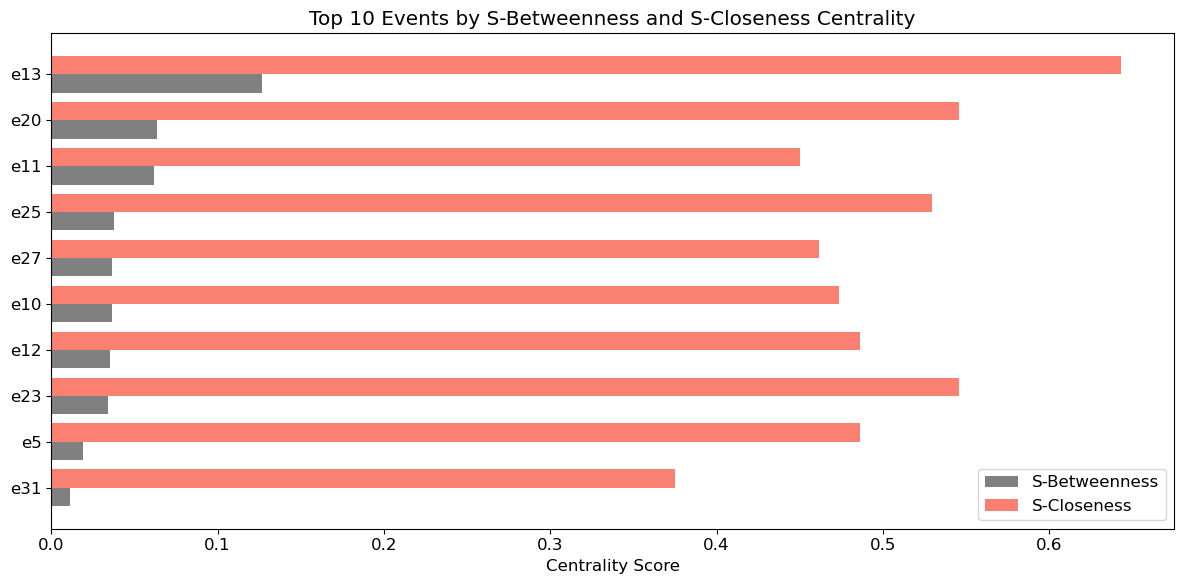

In [33]:
import matplotlib.pyplot as plt
import pandas as pd
from hypernetx.algorithms.s_centrality_measures import (
    s_betweenness_centrality,
    s_closeness_centrality
)

# Compute s=1 centralities
s = 1
bet_centrality = s_betweenness_centrality(H, s=s)
close_centrality = s_closeness_centrality(H, s=s)

# Combine into a DataFrame
df = pd.DataFrame([
    {
        "Event": node,
        "S-Betweenness Centrality": bet_centrality.get(node, 0.0),
        "S-Closeness Centrality": close_centrality.get(node, 0.0)
    }
    for node in set(bet_centrality) | set(close_centrality)
])

# Sort and take top N
N = 10  # Top N events
df_top = df.sort_values(by="S-Betweenness Centrality", ascending=False).head(N)

# Plot
fig, ax = plt.subplots(figsize=(12, 6))
bar_width = 0.4
x = range(len(df_top))

# Plot bars with new colors
ax.barh([i + bar_width for i in x], df_top["S-Betweenness Centrality"], bar_width, 
        color='grey', label="S-Betweenness")
ax.barh(x, df_top["S-Closeness Centrality"], bar_width, 
        color='salmon', label="S-Closeness")

# Labeling
ax.set_yticks([i + bar_width / 2 for i in x])
ax.set_yticklabels(df_top["Event"])
ax.invert_yaxis()
ax.set_xlabel("Centrality Score")
ax.set_title(f"Top {N} Events by S-Betweenness and S-Closeness Centrality")
ax.legend()
plt.tight_layout()
plt.show()


In [ ]:
import networkx as nx
from hypernetx.algorithms.s_centrality_measures import (
    s_harmonic_centrality,
    s_eccentricity
)
import pandas as pd

# Set the s-walk parameter
s = 1

# Compute S-Harmonic Centrality (works fine even if disconnected)
harm_centrality = s_harmonic_centrality(H, s=s)

# Try computing eccentricity, handle disconnected graphs gracefully
try:
    ecc_centrality = s_eccentricity(H, s=s)
except nx.NetworkXError:
    print("Graph is disconnected. Falling back to component-wise eccentricity.")
    linegraph = H.get_linegraph(s=s)
    ecc_centrality = {}
    for component in nx.connected_components(linegraph.to_undirected()):
        subgraph = linegraph.subgraph(component)
        ecc = nx.eccentricity(subgraph)
        ecc_centrality.update(ecc)

# Combine into a table
df = pd.DataFrame([
    {
        "Event": node,
        "S-Harmonic Centrality": harm_centrality.get(node, 0.0),
        "S-Eccentricity": ecc_centrality.get(node, float("inf"))
    }
    for node in set(harm_centrality) | set(ecc_centrality)
])

df = df.sort_values(by="S-Harmonic Centrality", ascending=False)
print(df)


Graph is disconnected. Falling back to component-wise eccentricity.
                                                Event  S-Harmonic Centrality  \
26  Chitosan, silver nanoparticles, and gelatin fu...              11.583333   
28  Chitosan and citric acid together reinforce po...              11.000000   
24  Chitosan, gelatin, calcium phosphate, and glyc...              10.916667   
6   Bacterial cellulose, citric acid, zinc oxide, ...              10.833333   
19  Chitosan and genipin crosslink to form a bioco...              10.250000   
3   Only when polyvinyl alcohol, citric acid, and ...               9.500000   
2   Polyethylene oxide and gelatin, when combined ...               9.366667   
14  Bacterial cellulose and genipin, reinforced wi...               9.000000   
0   Without gelatin, hyaluronic acid, and freeze-t...               8.866667   
7   The cryogel network suitable for bone defect f...               8.866667   
17  Polyvinyl alcohol, starch, and zinc oxide blen..